In [1]:
import json
import os

import numpy as np
import pandas as pd

dir = '../data/results/experiments/new_beam_matching_experiment_21'

data_df = pd.read_csv(os.path.join(dir, 'data.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

data_df['n_best_pcis'] = data_df['n_best_pcis'].apply(lambda x: 'all' if np.isnan(x) else f'{int(x)}')
data_df['n_best_beams'] = data_df['n_best_beams'].apply(lambda x: 'all' if np.isnan(x) else f'{int(x)}')

data_df['mnc'] = data_df['mnc'].astype('int')


def get_strat(row):
    if row['n_best_pcis'] == 'all' and row['n_best_beams'] == 'all':
        return 'All PCIs and all beams'
    elif row['n_best_pcis'] == '1' and row['n_best_beams'] == 'all':
        return 'Only best PCI and all beams'
    elif row['n_best_pcis'] == 'all' and row['n_best_beams'] == '1':
        return 'All PCIs and only best beam'
    elif row['n_best_pcis'] == '1' and row['n_best_beams'] == '1':
        return 'Only best PCI and only best beam'
    return 'unknown strategy'


data_df['config'] = data_df.apply(get_strat, axis=1)
config

{'wknn_k': 2,
 'rf_param': 'rsrq',
 'operator_choice': [1, 10, 50, 88],
 'n_runs': 20,
 'campaigns': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20],
 'n_clusters': 10,
 'runtime': 500.8057789802551}

In [2]:
a = np.array([2.4, 15.4, 11.5, 8.9]).mean()

#b = np.array([1.4, 2.0, 1.5, 1.9]).mean()
c = np.array([2.5, 9, 5.7, 7.1]).mean()

(a - c) / a * 100

np.float64(36.38743455497384)

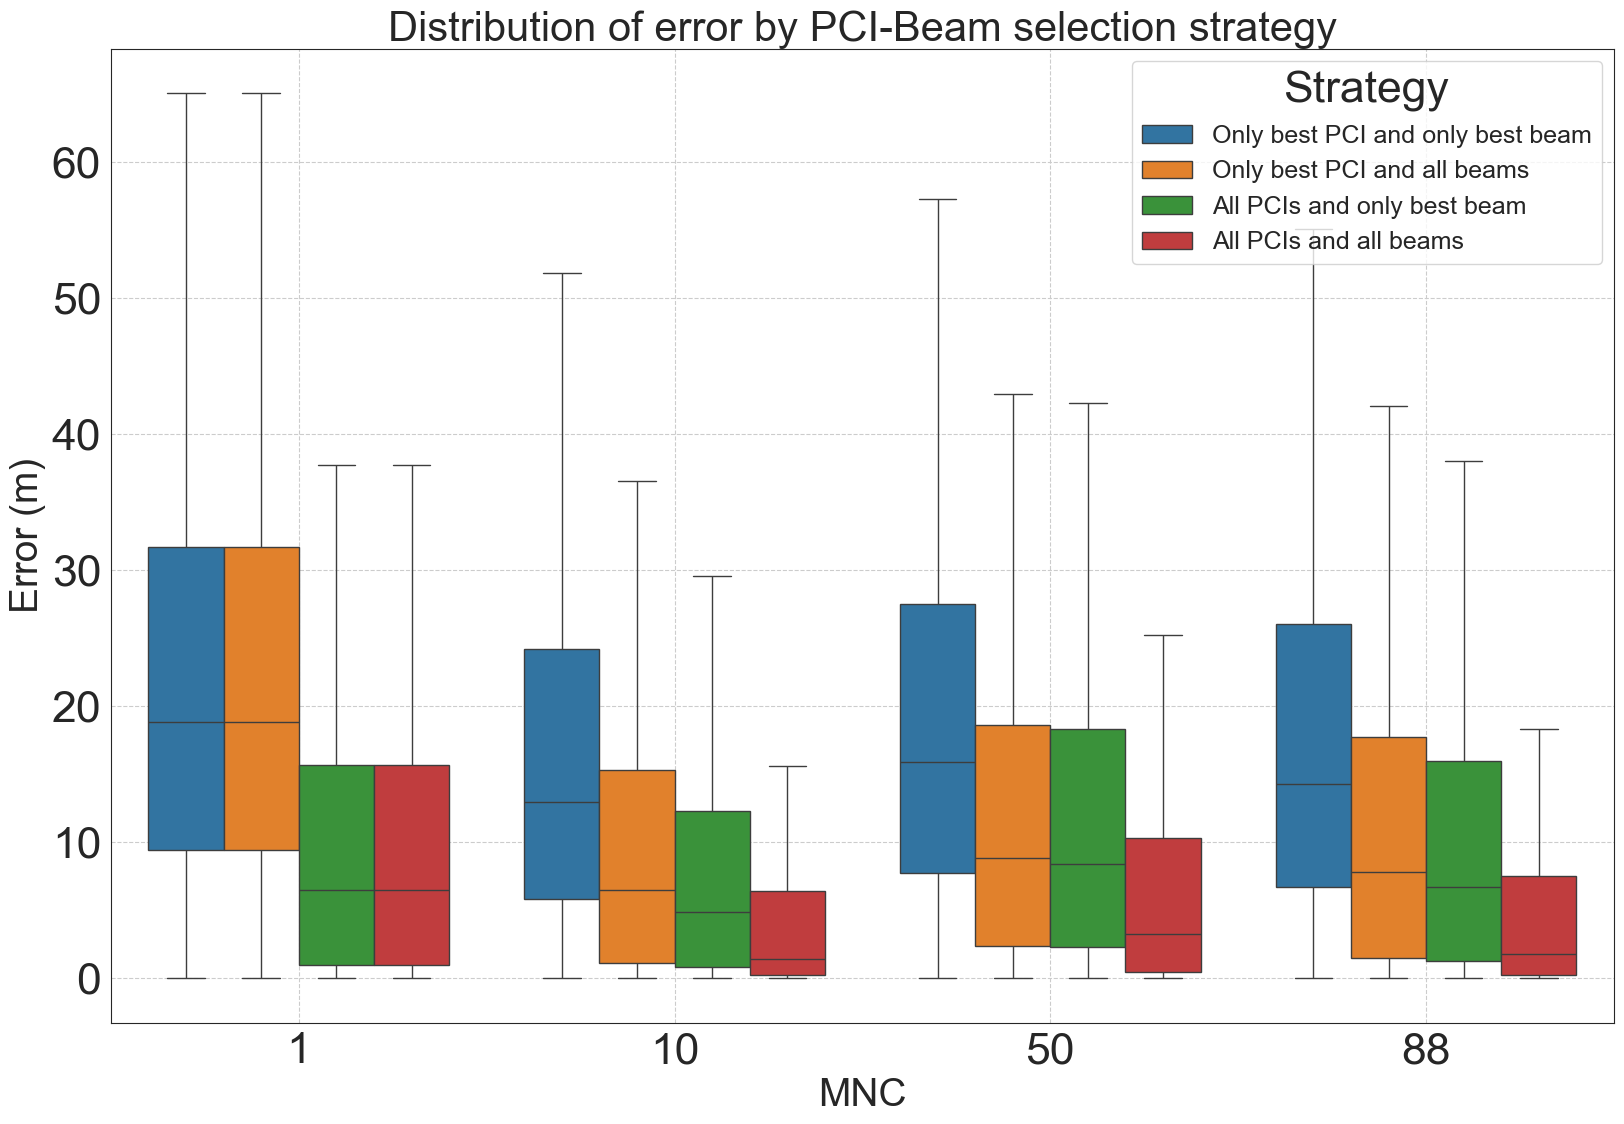

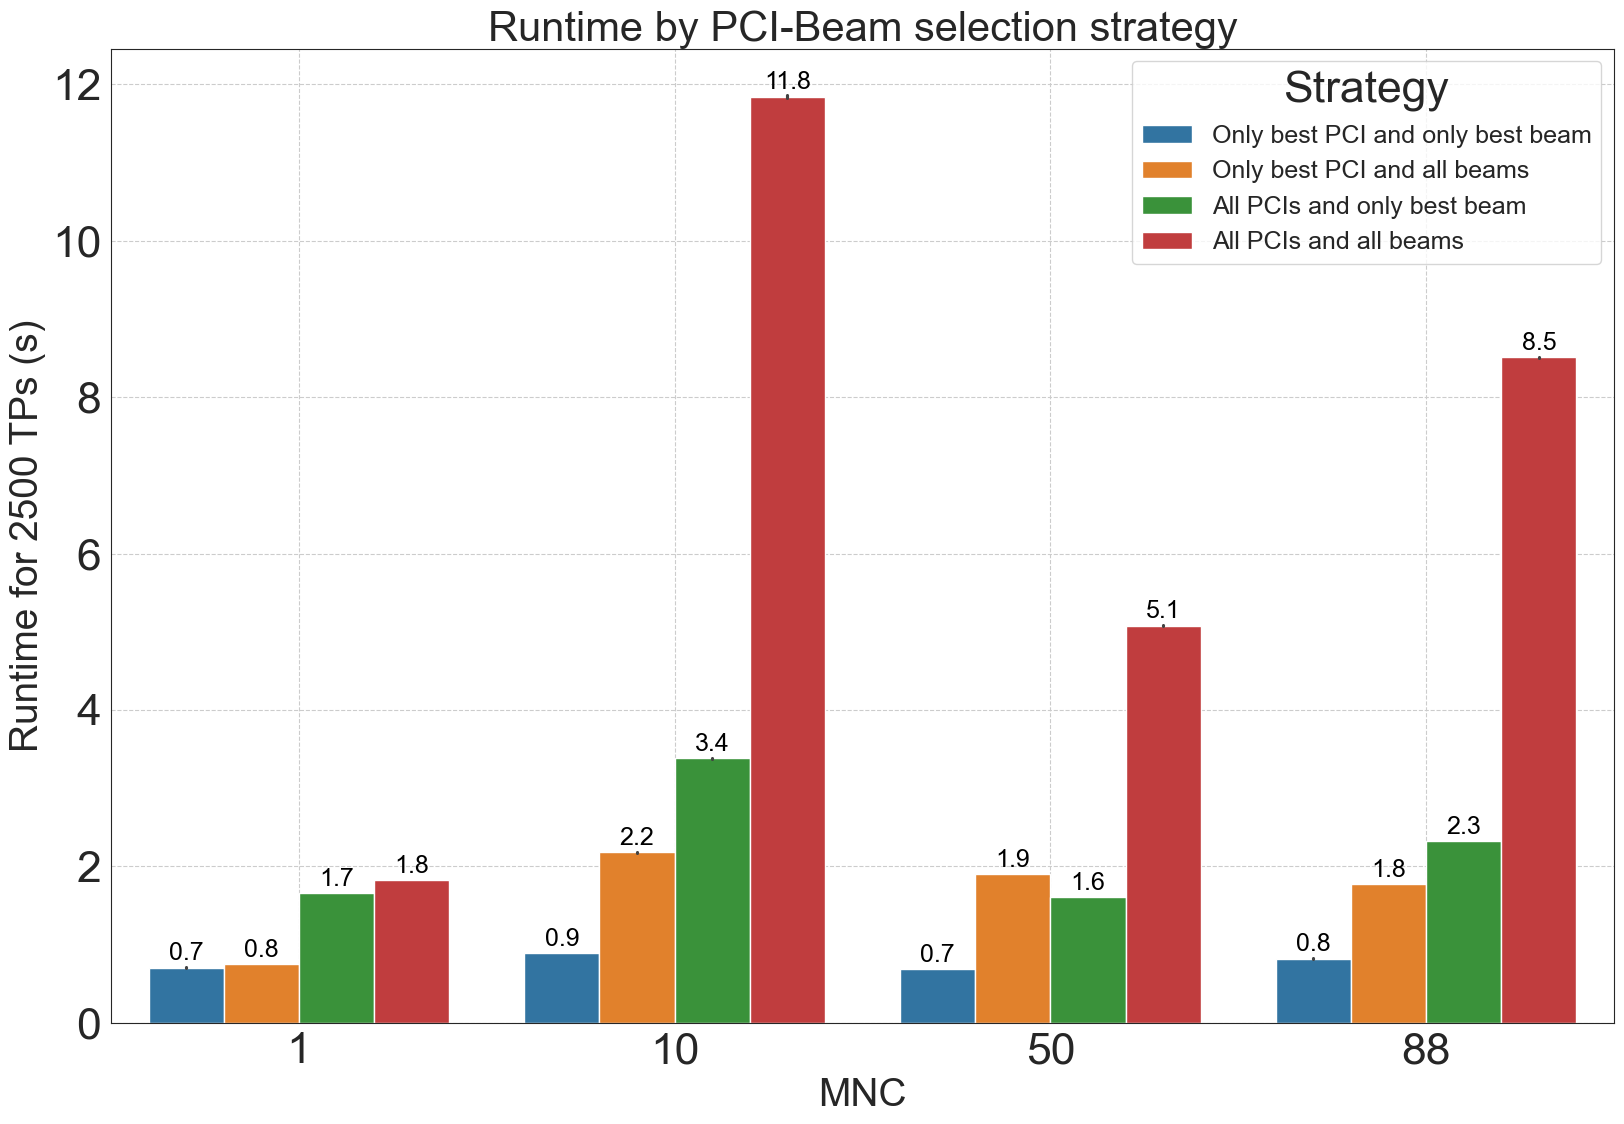

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({"font.size": 32})


def plot_operator(
        df: pd.DataFrame,
        y: str,
        x_label: str,
        y_label: str,
        title: str,
        box: bool
):
    hue_order = [
        'Only best PCI and only best beam',
        'Only best PCI and all beams',
        'All PCIs and only best beam',
        'All PCIs and all beams',
    ]

    plt.figure(figsize=(17, 12))

    sns.set_style("white")

    if box:
        bar_plot = sns.boxplot(
            data=df,
            x='mnc',
            y=y,
            hue='config',
            hue_order=hue_order,
            showfliers=False,
        )


    else:
        bar_plot = sns.barplot(
            data=df,
            x='mnc',
            y=y,
            hue='config',
            hue_order=hue_order,
        )
        # Annotate each bar with values in 'k' format
        for p in bar_plot.patches:
            height = p.get_height()
            if height != 0:  # Check if the height is not zero
                bar_plot.annotate(f'{height:,.1f}',  # Changed to use 'k' format
                                  (p.get_x() + p.get_width() / 2., height),
                                  ha='center', va='center',
                                  fontsize=18, color='black', xytext=(0, 10),
                                  textcoords='offset points')

    # Format y-axis in thousands
    #formatter = FuncFormatter(lambda x, _: f'{x / 1000:,.0f}k')
    #plt.gca().yaxis.set_major_formatter(formatter)  # Uncommented this line

    # Add labels and title
    plt.xlabel(x_label, fontsize=28)
    plt.ylabel(y_label, fontsize=28)
    plt.title(title, fontsize=30)
    #plt.ylim((-5, 80))

    plt.legend(title='Strategy', loc='upper right', fontsize=18, ncol=1 if box else 1)
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()


plot_operator(data_df, 'errors', 'MNC', 'Error (m)', 'Distribution of error by PCI-Beam selection strategy', box=True)
plot_operator(data_df, 'runtime', 'MNC', 'Runtime for 2500 TPs (s)', 'Runtime by PCI-Beam selection strategy',
              box=False)


In [14]:
items = data_df.groupby('config')['runtime'].mean()

data = items.to_dict()
base = data['All PCIs and all beams']

for conf, val in data.items():
    reduction = (base - val) / base * 100
    diff = val / base
    print(f'{conf}: {val}\t {reduction:.0f}% x {diff:.1f}')

items

All PCIs and all beams: 6.831333475386096	 0% x 1.0
All PCIs and only best beam: 2.2450726510320793	 67% x 0.3
Only best PCI and all beams: 1.6521932865866726	 76% x 0.2
Only best PCI and only best beam: 0.7760076801606381	 89% x 0.1


config
All PCIs and all beams              6.831333
All PCIs and only best beam         2.245073
Only best PCI and all beams         1.652193
Only best PCI and only best beam    0.776008
Name: runtime, dtype: float64

In [6]:
single_pci = (data['Only best PCI and only best beam'] + data['Only best PCI and all beams']) / 2
multi_pci = (data['All PCIs and only best beam'] + data['All PCIs and all beams']) / 2

print(single_pci)
print(multi_pci)
(single_pci - multi_pci) / single_pci * 100

1.2141004833736555
4.538203063209087


-273.79138921011327